A partir d'une base de donnée fictive de l'APHP nous souhaitons étudier les facteurs de risques du cancer du sein.

Avant toute chose, nous initialisons le notebook avec les librairies python qui serviront par la suite.

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import lifelines
import altair as alt
import spacy as spacy
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from edsnlp.processing.parallel import pipe as parallel_pipe
from spacy import displacy
from statsmodels.formula.api import logit, glm
alt.data_transformers.enable('default', max_rows=None)
t_end_of_study = datetime.date(2025,12,1)

On commence par importer l'ensemble des tables.

In [80]:
df_person = pd.read_pickle('data/df_person.pkl')
df_condition = pd.read_pickle('data/df_condition.pkl')
df_visit = pd.read_pickle('data/df_visit.pkl')
df_dedup = pd.read_pickle('data/df_dedup.pkl')
df_dedup_det = pd.read_pickle('data/df_dedup_deterministic.pkl')
df_dedup_proba = pd.read_pickle('data/df_dedup_proba.pkl')
df_note = pd.read_pickle('data/df_note.pkl')
df_bio = pd.read_pickle('data/df_bio.pkl')

Etudions en premier lieu la table df_person.

In [81]:
df_person.info()
df_person.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16168 entries, 0 to 216
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   birth_datetime       16168 non-null  datetime64[ns]
 1   death_datetime       8848 non-null   datetime64[ns]
 2   gender_source_value  16168 non-null  object        
 3   cdm_source           16168 non-null  object        
 4   person_id            16168 non-null  object        
dtypes: datetime64[ns](2), object(3)
memory usage: 757.9+ KB


,birth_datetime,death_datetime,gender_source_value,cdm_source,person_id
0,2016-08-02,2024-06-17,female,EHR 1,86484326
1,2013-11-01,2022-01-23,female,EHR 1,89213495
2,2013-04-02,2022-02-27,f,EHR 1,88207887
3,2016-08-19,2021-09-24,f,EHR 1,80499395
4,2022-06-04,2022-11-01,f,EHR 1,84190053


La table df_person offre des informations sur la population a étudier.

In [82]:
print(f"Il y a " + str(len(df_person.person_id.unique())) + " personnes différentes dans l'étude, dont 10235 femmes et 5933 hommes.")
df_person.groupby("gender_source_value").person_id.count()

Il y a 16168 personnes différentes dans l'étude, dont 10235 femmes et 5933 hommes.


gender_source_value
f         5099
female    5136
m         2951
male      2982
Name: person_id, dtype: int64

Il est nécessaire d'obtenir quelques informations supplémentaires sur notre base de donnée, pour cela intéressons nous à la table recensant les consultations.

In [83]:
df_visit.info()
df_visit.head()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 16168 entries, 0 to 216
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   visit_occurrence_id   16168 non-null  float64       
 1   care_site_id          16168 non-null  object        
 2   visit_start_datetime  16168 non-null  datetime64[ns]
 3   visit_end_datetime    16137 non-null  datetime64[ns]
 4   visit_source_value    16168 non-null  object        
 5   person_id             16168 non-null  object        
dtypes: datetime64[ns](2), float64(1), object(3)
memory usage: 884.2+ KB


,visit_occurrence_id,care_site_id,visit_start_datetime,visit_end_datetime,visit_source_value,person_id
0,82199313.0,Clinique L.Pasteur,2020-01-12,2020-01-27,Hospitalisés,87118775
1,84796321.0,Hopital M.Bres,2023-09-05,2023-09-21,Hospitalisés,85828583
2,83914646.0,Centre F.Sinoussi,2019-12-28,2020-01-12,Hospitalisés,88459112
3,84893973.0,Centre F.Sinoussi,2020-12-26,2020-12-26,Hospitalisés,88291057
4,88339649.0,GHU A.Fleming,2024-12-14,2025-01-03,Hospitalisés,89239332


In [84]:
df_condition.info()
df_condition.head()
df_visit.care_site_id.value_counts()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 24486 entries, 0 to 269
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   visit_occurrence_id      24486 non-null  float64
 1   person_id                24486 non-null  object 
 2   condition_occurrence_id  24486 non-null  float64
 3   condition_source_value   24486 non-null  object 
dtypes: float64(2), object(2)
memory usage: 956.5+ KB


Clinique L.Pasteur    4070
GHU A.Fleming         4064
Centre F.Sinoussi     4043
Hopital M.Bres        3991
Name: care_site_id, dtype: int64

Il y a donc quatre hôpitaux avec environ 4000 visites par site.

Il faut ensuite vérifier que les données sont cohérentes.

On s'intéresse à la date d'entrée et de sortie des patients à l'hôpital.

In [85]:
df_visit['visit_start_date'] = df_visit['visit_start_datetime'].dt.strftime('%Y-%m')
df_visit['visit_end_date'] = df_visit['visit_end_datetime'].dt.strftime('%Y-%m')

visit_start_dates_summary = df_visit.groupby("visit_start_date", as_index=False).person_id.count()
visit_end_dates_summary = df_visit.groupby("visit_end_date", as_index=False).person_id.count()

Pour mieux visualiser les incohérences, on affiche ces données sur un diagramme. Le premier diagramme représente les dates d'entrés et le second celles de sorties.

In [86]:
alt.Chart(visit_start_dates_summary).mark_bar().encode(
    x='visit_start_date:T',
    y='person_id:Q'
)

alt.Chart(...)

In [87]:
alt.Chart(visit_end_dates_summary).mark_bar().encode(
    x='visit_end_date:T',
    y='person_id:Q'
)

alt.Chart(...)

On constate qu'il n'y a pas d'incohérence notable.

In [88]:
print(f"Il y a " +str(len(df_person.cdm_source.unique())) + " logiciel utilisés par les médecins")
missing_number=df_person.loc[df_person.cdm_source=='EHR 1'].birth_datetime.isna().sum()
print(f"Ceci explique qu'il y ait " + str(missing_number) + " date de naissance manquante.")

Il y a 1 logiciel utilisés par les médecins
Ceci explique qu'il y ait 0 date de naissance manquante.


In [89]:
df_person['birth_date'] = df_person['birth_datetime'].dt.strftime('%Y-%m')
birth_dates_summary = df_person.groupby("birth_date", as_index=False).person_id.count()
alt.Chart(birth_dates_summary).mark_bar().encode(
    x='birth_date:T',
    y='person_id:Q'
)

alt.Chart(...)

Ce graphique illustre la répartition des dates de naissances de notre base de donnée. Sur ce point non plus, rien d'incohérent n'est à noter.

In [90]:
print(f"Les différentes conditions répertoriées dans la table sont : {df_condition.condition_source_value.unique()}")

Les différentes conditions répertoriées dans la table sont : ['C19' 'F023' 'G20' 'C34' 'Z803' 'Z720' 'C504' 'C50' 'C502' 'C500' 'C501'
 'C503' 'K70' 'F10' 'Z587' 'T51' 'Z864' 'E10' 'E12' 'I13' 'I12' 'I15'
 'E11' 'Z716' 'B22' 'B21']


Pour pouvoir exploiter ses informations, il est nécessaire de savoir à quel diagnostic elles correspondent. Après utilisation de Aide au Codage nous obtenons la correspondance suivante :  
C19 : Tumeur maligne de la jonction recto-sigmoïdienne  
F023 : Démence de la maladie de Parkinson  
G20 : Maladie de Parkinson  
C34 : Tumeur maligne des bronches et du poumon  
Z803 : Antécédents familiaux de tumeur maligne du sein    
C504 : Tumeur maligne du quadrant supéro-externe du sein  
Z720 : Difficultés liées à l'usage du tabac  
C50 : Tumeur maligne du sein  
C502 : Tumeur maligne du quadrant supéro-interne du sein  
C501 : Tumeur maligne de la partie centrale du sein  
C500 : Tumeur maligne du mamelon et de l'aréole  
B21 : Immunodéficience humaine virale [VIH], à l'origine de tumeurs malignes  
B22 : Immunodéficience humaine virale [VIH], à l'origine d'autres affections précisées  
Z716 : Conseil pour tabagisme  
E11 : Diabète sucré de type 2  
I15 : Hypertension secondaire  
I12 : Néphropathie hypertensive  
E12 : Diabète sucré de malnutrition  
I13 : Cardionéphropathie hypertensive  
E10 : Diabète sucré de type 1  
Z864 : Antécédents personnels d'abus de substances psycho-actives  
T51 : Effet toxique de l'alcool  
Z587 : Exposition à la fumée du tabac  
F10 : Troubles mentaux et du comportement liés à l'utilisation d'alcool  
K70 : Maladie alcoolique du foie  
C503 : Tumeur maligne du quadrant inféro-interne du sein  

De ces catégories nous pouvons en retenir 11 plus générales :   
-Cancer du sein   
-Tabac  
-Cancer du colon   
-Maladie de Parkinson  
-Cancer du poumon  
-Antécédents familiaux de tumeur maligne du sein
-VIH  
-Diabète  
-Hypertension  
-Consomation de substances psycho-actives  
-Alcool

In [91]:
cancer_sein = ['C50', 'C500', 'C501', 'C502', 'C503', 'C504']
tabac = ['Z720', 'Z716', 'Z587']
cancer_colon = ['C19']
parkinson = ['G20', 'F023']
cancer_poumon = ['C34']
antécédents = ['Z803']
VIH = ['B21', 'B22']
diabète = ['E11', 'E12', 'E10']
hypertension = ['I15', 'I12', 'I13']
substances = ['Z864']
alcool = ['T51','F10','K70']

Cela nous permet de dénombrer le nombre de personnes de notre étude ayant un cancer du sein et ainsi savoir s'il est possible d'en tirer des conclusions.

In [92]:
df_condition_cancer = df_condition[df_condition['condition_source_value'].isin(cancer_sein)]
nb_cancer_sein=len(df_condition_cancer.person_id.unique())
print('Il y a ' + str(nb_cancer_sein) + " personnes atteintes d'un cancer du sein.")

df_person_condition = df_person.merge(df_condition, left_on='person_id', right_on='person_id')
df_femme_cancer = df_person_condition[(df_person_condition['gender_source_value'].isin(['f','female']))&(df_person_condition['condition_source_value'].isin(cancer_sein))]

print('Parmi ces ' + str(nb_cancer_sein)  + ' persones,' + ' ' + str(len(df_femme_cancer.person_id.unique())) + ' sont des femmes.')


Il y a 4327 personnes atteintes d'un cancer du sein.
Parmi ces 4327 persones, 4327 sont des femmes.


Aucun homme atteint d'un cancer du sein n'est présent dans cette étude. Nous ne pourrons donc pas étudier les cancers du sein touchant les hommes. L'étude se portera donc sur les femmes.

Pour réaliser un tri de nos données, on utilise une structure de dictionnaire

In [93]:
dic = {'cancer_sein' : ['C50', 'C500', 'C501', 'C502', 'C503', 'C504'], 
    'tabac' : ['Z720', 'Z716', 'Z587'], 
    'cancer_colon' : ['C19'],
    'parkinson' : ['G20', 'F023'],
    'cancer_poumon' : ['C34'],
    'antécédents' : ['Z803'],
    'sida' : ['B21', 'B22'],
    'diabète' : ['E11', 'E12', 'E10'],
    'hypertension' : ['I15', 'I12', 'I13'],
    'substances' : ['Z864'],
    'alcool' : ['T51', 'F10', 'K70']}

On va dans un premier temps éliminer les hommes de nos données

In [94]:
df_person=df_person[df_person["gender_source_value"].isin(['f',"female"])]
f_person_id=df_person["person_id"]

df_dedup_det=df_dedup_det[df_dedup_det["person_id"].isin(f_person_id)]
df_dedup_proba=df_dedup_proba[df_dedup_proba["person_id"].isin(f_person_id)]
df_dedup=df_dedup[df_dedup["person_id"].isin(f_person_id)]
df_visit=df_visit[df_visit["person_id"].isin(f_person_id)]
df_conditon=df_condition[df_condition["person_id"].isin(f_person_id)]

 Ici, on va considérer des données qui ont pour clé un numéro de visite. Pour cela, on crée une liste avec les numéros de visites correspondant aux visites des femmes uniquemement.

In [ ]:
visits=df_visit["visit_occurrence_id"]
df_bio=df_bio[df_bio["visit_occurrence_id"].isin(visits)]
df_note=df_note[df_note["visit_occurrence_id"].isin(visits)]

Maintenant que nos tables ne concernent que des femmes, on se demande si un même individu se voit donner le même diagnostic lors de plus de 2 visites différentes. Cela serait problématique dans le comptage du nombre d'individus atteints d'un type de maladie (on compterait des doublons)

On cherche à écrire une fonction qui donne le type de maladies pour un ICD donné

In [95]:
def classe(x):
    for cle in dic:
        if x in dic[cle]:
            return cle 

def del_cond_redondante(df_cond):
    df_cond_fix=df_cond
    classes=[classe(x) for x in df_cond_fix['condition_source_value']]
    df_cond_fix['classes']=classes
    df_cond_fix=df_cond_fix.drop_duplicates(subset=['person_id','classes'])
    df_cond_fix=df_cond_fix.drop("classes",axis=1)
    return df_cond_fix

len(del_cond_redondante(df_condition))==len(df_condition)

True


On remarque alors que la table obtenue après élimination des diagonistics identiques pour un même patient pour des visites différentes est de la même taille que la table intitiale, ainsi il n'existe pas deux visites différentes avec le même patient et le même diagnostic

Enfin, on va réaliser une déduplication des données. En effet, certains patients ont été référencés avec deux identifiants différents alors qu'il s'agit de la même personne. 
Tout d'abord, on réalise une déduplication déterministe

In [96]:
# Outer Join
df_person_dedup_det = df_person.merge(df_dedup_det, left_on='person_id',right_on="person_id", how="outer")

# Complete the unique_person_id column
df_person_dedup_det['unique_person_id'] =df_person_dedup_det['unique_person_id'].fillna(df_person_dedup_det['person_id'])

df_person_dedup_det=df_person_dedup_det.drop_duplicates(subset=['unique_person_id'])

n=len(df_person_dedup_det)
print(f"En utilisant l'algorithme déterministe, nous avons {str(n)} identifiants uniques de patientes dans cet ensemble de données.")

En utilisant l'algorithme déterministe, nous avons 9987 identifiants uniques de patientes dans cet ensemble de données


On réalise ensuite une déduplication probabiliste afin de réaliser un appareillement plus réaliste.

In [97]:
def deduplicate_proba(df_person, df_dedup_proba, score):
    df_dedup_proba_score=df_dedup_proba[df_dedup_proba["prob"]>score]
    df_person_dedup_proba=df_person.merge(df_dedup_proba_score, on="person_id", how="outer")
    df_person_dedup_proba['unique_person_id'] =df_person_dedup_proba['unique_person_id'].fillna(df_person_dedup_proba['person_id'])
    df_person_dedup_proba=df_person_dedup_proba.drop_duplicates(subset=['unique_person_id'])
    return df_person_dedup_proba


Nous avons 10235 identifiants de patients uniques dans cet ensemble de données lorsque nous utilisons l'algorithme probabiliste et un seuil de 0,90.


Maintenant, il s'agit de déterminer le seuil idéal pour que l'identification de deux identifiants en un unique patient soit la plus cohérente possible 

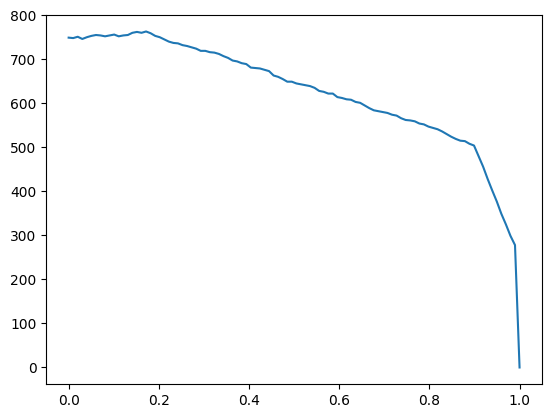

In [98]:
n=len(df_person)
X=np.linspace(0,1,100)
Y=[]
for x in X:
    df_person_dedup_proba_1 = deduplicate_proba(df_person, df_dedup_proba,x)
    Y.append(n-df_person_dedup_proba_1.unique_person_id.nunique())
plt.plot(X,Y)
plt.show()

On remarque alors que le seuil de 0,90 est critique : à partir de ce seuil, le nombre de doublons détectés diminue très rapidement, ce qui signifie que le taux de ressemblance delandé est trop importante pour dire que deux patients sont uniques.

In [ ]:
df_person_dedup_proba_90 = deduplicate_proba(df_person, df_dedup_proba,0.90)  
print(f"En utilisant l'algorithme probabiliste avec un seuil de 0.90, nous avons {df_person_dedup_proba_90.unique_person_id.nunique()} identifiants uniques de patientes dans cet ensemble de données.")

In [ ]:
df_person_dedup_proba_90=df_person_dedup_proba_90.drop("unique_person_id",axis=1)
df_person_dedup_proba_90=df_person_dedup_proba_90.drop("prob",axis=1)

 Maintenant il faut définir des fonctions qui permettent de retirer les doublons dans les autres tables

In [ ]:
df_person=df_person_dedup_proba_90
f_person_id=df_person_dedup_proba_90['person_id']
df_visit=df_visit[df_visit['person_id'].isin(f_person_id)]
list_visits=df_visit["visit_occurrence_id"]
df_bio=df_bio[df_bio["visit_occurrence_id"].isin(list_visits)]
df_note=df_note[df_note["visit_occurrence_id"].isin(list_visits)]

Les données présentes dans les tables ne sont généralement pas complètes. En particulier, les informations liées au tabagisme sont souvent manquantes. Ces précieuses informations se retrouvent dans les comptes rendus médicaux, il est donc intéressant de pouvoir extraire ces données de ces documents afin de mettre en lumière le lien entre tabagisme et cancer du sein. A partir de ces comptes rendus, nous allons donc essayer de déterminer pour chaque personne de la base de donnée si elle fume ou non.

Dans un premier temps nous allons mettre en place un code permettant de lire le compte rendu correspondant à une visite donnée.

In [99]:
def note(x):

    def note_text(x):
        return df_note[df_note["visit_occurrence_id"]==x]
    return df_note[df_note["visit_occurrence_id"]==x].sample(1)['note_text'].squeeze()

In [100]:
print(note(82199313.0))

Compte rendu de consultation

Patient : [Nom du patient]
Âge : [Âge du patient]
Sexe : [Sexe du patient]
Numéro de dossier : [Numéro de dossier du patient]

Motif de la consultation:
La patiente a été référée pour une évaluation spécialisée après la découverte d'une masse mammaire lors d'un examen de dépistage. Cependant, une biopsie a révélé que la masse était bénigne, éliminant ainsi les inquiétudes concernant un cancer du sein.

Antecedents familiaux :
Les antécédents médicaux de la patiente révèlent que ses parents sont des fumeurs chroniques, ce qui peut avoir des répercussions sur sa propre santé respiratoire.

Examen du patient:
La patiente a déclaré qu'elle a toujours privilégié un mode de vie axé sur la santé, ce qui inclut l'absence de consommation de tabac, confirmant ainsi qu'elle ne fume pas.

Signature du médecin :
[Nom du médecin]
[Titre/Spécialité]
[Hôpital/Service]


Il est ainsi possible de lire plusieurs comptes rendus, de ces lectures il ressort une liste de termes permettant de caractériser le tabagisme. Nous allons alors définir une liste de mots dont leur apparition ou non dans un compte rendu permettera de décider si la personne associée à ce document est fumeuse.

In [101]:
terms = dict(
    tabac=['fumeuse', 'tabagisme', 'nicotine','fumeur', 'cigarettes', 'cigarette', 'fumer', 'fumée', 'tabac', 'fument', 'fumeurs', 'fume', 'fumeuses', 'fumées','fumé'] 
 )

Il est également important de remarquer que l'étude de la section antécédents familiaux n'est pas des plus pertinente, en effet savoir que les grands-parents d'une personne fument n'implique pas que cette personne fume. Au contraire, l'étude de cette section par nos algorithmes pourrait biaser les résultats. En effet, la mention "son frère ne fume pas" pourrait très bien apparaître dans cette section, l'algorithme détecterait alors la mention "ne fume pas" et le catégoriserait comme non fumeur, et ce même si rien dans le compte rendu ne semble indiquer cela. Il est donc intéressant de réussir à ne selectionner que la partie du texte "Examen du patient".

In [102]:
def couper_texte(texte):
    for i in range(len(texte)-len("Examen du patient")):
        if texte[i:i+len("Examen du patient")]== "Examen du patient":
            return texte[i:]

In [103]:
print(couper_texte(note(82199313.0)))

Examen du patient:
La patiente a déclaré qu'elle a toujours privilégié un mode de vie axé sur la santé, ce qui inclut l'absence de consommation de tabac, confirmant ainsi qu'elle ne fume pas.

Signature du médecin :
[Nom du médecin]
[Titre/Spécialité]
[Hôpital/Service]


Il est ensuite nécessaire de dénfinir les structures qui permettront d'étudier les textes. Il faudra en particulier que l'algorithme soit capabale de dire si les termes ci-dessus apparaissent dans les textes, et soit capable de répérer les négations. Autrement dit, l'algorithme doit être en mesure de déterminer si une personne fume ou si elle ne fume pas. 

In [104]:
nlp = spacy.blank("fr")
# sentencizer component
nlp.add_pipe('eds.sentences')
nlp.add_pipe("eds.normalizer")
# Matcher component
nlp.add_pipe("eds.matcher", config=dict(terms=terms))
nlp.add_pipe("eds.negation")

L'algotitme mis en place ci-dessous permet de mettre en évidence l'apparition de temres relatifs au tabagisme.

In [105]:
def afficher(x):

    text = couper_texte(note(x))

    # Process your text in one call !
    doc = nlp(text)

    colors = {
        "tabac": "orange"
    }
    options = {
        "colors": colors,
    }

    displacy.render(doc, style="ent", options=options)

afficher(83557901.0)

La fonction créée ci-dessous fournit les données qui doivent être collectées par l'algorithme.

In [106]:
def pick_results(doc):

    return [{
             'note_id':e.doc._.note_id,
             'visit_occurrence_id':e.doc._.visit_occurrence_id,
             'lexical_variant':e.text,
             'label':e.label_,
             'negation':e._.negation
             } 
             for e in doc.ents if doc.ents]

Il faut ensuite mettre ces données collectées sous la forme d'une table.

In [107]:
ents = parallel_pipe(
                df_note,
                nlp,
                context=['note_id', 'visit_occurrence_id'],
                progress_bar=False,
                n_jobs=1, 
                results_extractor = pick_results,
                )

ents

,note_id,visit_occurrence_id,lexical_variant,label,negation
0,87594092.0,86526573.0,fumée,tabac,True
1,87594092.0,86526573.0,tabagisme,tabac,False
2,87594092.0,86526573.0,fumée,tabac,False
3,89266782.0,82217661.0,fumer,tabac,True
4,89266782.0,82217661.0,tabac,tabac,False
...,...,...,...,...,...
48750,82715079.0,86179649.0,fumeuse,tabac,False
48751,82715079.0,86179649.0,cigarettes,tabac,False
48752,82241061.0,88005668.0,nicotine,tabac,False
48753,82241061.0,88005668.0,tabagisme,tabac,False


Cette table contient les informations de si des mots relatifs au tabagisme apparaissent ou non dans le texte. Elle contient de plus l'information sur la présence ou non d'une négation associée à ces mots. De cette table il faut alors décider si une personne est ou non fumeuse.

Nous considérons que si l'algorithme détecte une négation liée au mot tabac alors la personne ne fume pas, et cela même si dans la suite du texte l'algorithme détecte l'absence de négation liée au mot tabac. Sans cette hypothèse l'algorithme renverrait une liste trop importante de personnes que l'algoritme ne peut qualifier de fumeuses ou de non fumeuses.

Nous affectons l'état control à une personne étant caractérisée comme non fumeuse, l'état tabac à une personne caractérisé comme fumeuse, unknown si aucun mot propre au tabac apparait.

In [108]:
def calc_value(x):
    state = "unknown"
    for _, row in x.iterrows():
        if row['label'] in ['tabac'] and row['negation']:
            state = "control"
            break
        elif row['label'] == 'tabac' and not row['negation']:
            if state == "unknown" or state == "tabac":
                state = "tabac"
            else:
                state = "ambiguous"
    return state

undesired_state = ['unknown', 'ambiguous']
ents_grouped = ents.groupby('visit_occurrence_id').apply(calc_value).to_frame('state').reset_index()
ents_grouped.sample(20)

,visit_occurrence_id,state
3080,81896939.0,control
3175,81962577.0,control
10611,86587289.0,tabac
10924,86771855.0,tabac
12912,88001489.0,control
2295,81404215.0,control
13138,88149071.0,control
8755,85452173.0,tabac
7915,84902916.0,control
12963,88038473.0,control


Afin de croiser les données cancer/tabac, il est nécessaire de disposer de la liste des personnes ayant un cancer.

In [112]:
df_cancer=df_condition[df_condition['condition_source_value'].isin(cancer_sein)]
df_cancer

,visit_occurrence_id,person_id,condition_occurrence_id,condition_source_value,classes
0,85885246.0,88368147,86103222.0,C504,cancer_sein
1,89449688.0,83876325,85183004.0,C504,cancer_sein
2,82732429.0,86058513,88366435.0,C50,cancer_sein
3,87671952.0,80974576,81001542.0,C502,cancer_sein
4,81135747.0,81279112,85011607.0,C500,cancer_sein
...,...,...,...,...,...
727,80046951.0,85973702,84294654.0,C503,cancer_sein
728,88468476.0,80302433,81662383.0,C500,cancer_sein
729,85625390.0,81637716,80858003.0,C504,cancer_sein
730,83195461.0,85076901,85612324.0,C500,cancer_sein


In [114]:
df_cancer.person_id.value_counts()

88368147    1
83531125    1
83890055    1
84454986    1
82141940    1
           ..
84613435    1
81090173    1
80725901    1
80483358    1
85409642    1
Name: person_id, Length: 4327, dtype: int64

On remarque d'ailleurs qu'aucune personne n'a fait plusieurs visites pour lesquelles elle aurait été diagnostiqué atteinte d'un cancer du sein, ce qui aurait pour effet de biaiser les résultats, puisqu'elle serait compter plusieurs fois.

Nous allons désormais créer deux tables qui permettent de distinguer les personnes catégorisées comme fumeuses et celles qui ne le sont pas.

In [116]:
df_tabac=ents_grouped[ents_grouped.state=='tabac']
df_no_tabac=ents_grouped[ents_grouped.state=='control']

On réalise ensuite une joiture pour obtenir une table dans laquelle apparaissent toutes les personnes qui fument et atteintes d'un cancer du sein.

In [117]:
df_cancer_tabac = df_cancer.merge(df_tabac, left_on='visit_occurrence_id',right_on="visit_occurrence_id", how="inner")
df_cancer_tabac

,visit_occurrence_id,person_id,condition_occurrence_id,condition_source_value,classes,state
0,89449688.0,83876325,85183004.0,C504,cancer_sein,tabac
1,82732429.0,86058513,88366435.0,C50,cancer_sein,tabac
2,87671952.0,80974576,81001542.0,C502,cancer_sein,tabac
3,81135747.0,81279112,85011607.0,C500,cancer_sein,tabac
4,81574054.0,85004512,80579669.0,C501,cancer_sein,tabac
...,...,...,...,...,...,...
2403,87831418.0,89030866,80405368.0,C503,cancer_sein,tabac
2404,88468476.0,80302433,81662383.0,C500,cancer_sein,tabac
2405,85625390.0,81637716,80858003.0,C504,cancer_sein,tabac
2406,83195461.0,85076901,85612324.0,C500,cancer_sein,tabac


La même chose peut être réalisée pour les personnes qui ne fument pas.

In [118]:
df_cancer_no_tabac = df_cancer.merge(df_no_tabac, left_on='visit_occurrence_id',right_on="visit_occurrence_id", how="inner")
df_cancer_no_tabac

,visit_occurrence_id,person_id,condition_occurrence_id,condition_source_value,classes,state
0,85885246.0,88368147,86103222.0,C504,cancer_sein,control
1,87386204.0,86958701,81618789.0,C501,cancer_sein,control
2,86377095.0,81219875,82695533.0,C504,cancer_sein,control
3,88066395.0,87689063,84855384.0,C503,cancer_sein,control
4,86423640.0,86040582,81643382.0,C504,cancer_sein,control
...,...,...,...,...,...,...
1906,87802370.0,83326283,87794297.0,C500,cancer_sein,control
1907,83073549.0,83199624,87332842.0,C500,cancer_sein,control
1908,86008090.0,81001260,86527150.0,C500,cancer_sein,control
1909,88099279.0,81646260,85790407.0,C503,cancer_sein,control


On remarque alors que sur 4327 femmes atteintes d'un cancer du sein, 2408 fumaient, soit 55,6%. Fumer augmenterait les risques de développer un cancer du sein de 26%.

On crée une nouvelle table avec seulement les informations qui nous intéresse depuis la table person_id pour la suite du traitement des données

In [ ]:
data = df_person[["person_id","birth_datetime"]]

On calcule l'age de chaque patient lors de sa visite à l'hôpital

In [ ]:
data = pd.merge(data, df_visit[["person_id", "visit_occurrence_id" ,"visit_start_datetime"]], on="person_id", how="inner")
data['age'] = (data['visit_start_datetime'] - data['birth_datetime']).dt.days/ 365

In [ ]:
dic = {'cancer_sein' : ['C50', 'C500', 'C501', 'C502', 'C503', 'C504'], 
    'tabac' : ['Z720', 'Z716', 'Z587'], 
    'cancer_colon' : ['C19'],
    'parkinson' : ['G20', 'F023'],
    'cancer_poumon' : ['C34'],
    'antécédents' : ['Z803'],
    'sida' : ['B21', 'B22'],
    'diabète' : ['E11', 'E12', 'E10'],
    'hypertension' : ['I15', 'I12', 'I13'],
    'substances' : ['Z864'],
    'alcool' : ['T51', 'F10', 'K70']}

In [ ]:
code_to_comorb = {}
for key,codes_list in dic.items():
    for code in codes_list:
        code_to_comorb[code]=key

On crée une nouvelle colonne dans la table condition qui donne la comorbidité du patient, et on compte le nombre de patient atteint par chaque comorbidité

In [ ]:
df_condition["comorbidity"] = df_condition.condition_source_value.map(code_to_comorb)
df_comorbidities = df_condition[df_condition.comorbidity.notna()]
df_comorbidities.comorbidity.value_counts()

On pivote le DataFrame 'comorbidities' pour avoir la présence de toutes les comorbidités pour chaque patient. On remplace ensuite les valeurs NaN par False et on réinitialise l'index

In [ ]:
df_comorbidities["value"] = True
df_comorbidities = df_comorbidities.drop(columns=["condition_occurrence_id"]).pivot(index=["person_id", "visit_occurrence_id"], columns=["comorbidity"], values="value").reset_index().fillna(False)

In [ ]:
df_comorbidities.head()

On merge les DataFrames 'data' et 'comorbidités' pour résumer les informations sur les comorbidités pour chaque patient

In [ ]:
data = pd.merge(data, df_comorbidities[["person_id", "alcool", "antécédents","cancer_colon","cancer_poumon","cancer_sein","diabète","hypertension","parkinson","sida","substances","tabac"]], on="person_id", how="left").fillna({"alcool":False, "antécédents":False, "cancer_colon":False, "cancer_poumon":False, "cancer_sein":False, "diabète":False, "hypertension":False, "parkinson":False, "sida":False, "substances":False, "tabac":False})

On cherche les différentes valeurs biologiques disponibles puis on rajoute ces informations à notre DataFrame des comorbidités pour chaque patient de la même manière que précédemment

In [ ]:
df_bio.concept_source_value.value_counts()

In [ ]:
bio_processed = df_bio[["visit_occurrence_id", "concept_source_value", "transformed_value"]].pivot(index=["visit_occurrence_id"], columns="concept_source_value", values="transformed_value").reset_index()
bio_processed.head()

In [ ]:
data = pd.merge(data, bio_processed, on="visit_occurrence_id", how="left")

On garde les colonnes qui nous intéressent

In [ ]:
data = data[["person_id", "age", "alcool", "antécédents", "cancer_colon", "cancer_poumon", "cancer_sein", "diabète", "hypertension", "parkinson", "sida", "substances", "tabac", "bmi", "crp", "urea", "hb"]]

On vérifie que toutes les cases du tableaux sont complétées

In [ ]:
data.isna().sum(axis=0)

Il n'y a pas de valeur nulle : la base est prête à l'utilisation, le preprocessing est fini ... on peut enfin passer à l'étude statistique !

On définit les fonctions de prévalence (pour les données discrètes) et de médiane inter-quartile (pour les données continues)

In [ ]:
def prevalence(values):
    return round(values.sum()*100 / len(values),2)

def mediane_IQR(values):
    return str(round(values.median(), 2)) + ' (' + str(round(values.quantile(0.25), 2)) + '-' +  str(round(values.quantile(0.75), 2)) + ')'


On attribue à chaque caractéristique la méthode de calcul correspondante en fonction du type de données (discrètes ou continues)

In [ ]:
agg_dict = {
    "person_id": ["count"],
    "age": [mediane_IQR],
    "alcool": [prevalence],
    "antécédents" : [prevalence],
    "cancer_colon" : [prevalence],
    "cancer_poumon" : [prevalence],
    "diabète" : [prevalence],
    "hypertension" : [prevalence],
    "parkinson" : [prevalence],
    "sida" : [prevalence],
    "substances" : [prevalence],
    "tabac" : [prevalence],
    "bmi" : [mediane_IQR],
    "crp": [mediane_IQR],
    "hb": [mediane_IQR],
    "urea": [mediane_IQR],
}

numerical = ["age", "bmi", "crp", "hb", "urea"]
test_categorical = ["alcool", "antécédents", "cancer_colon", "cancer_poumon", "diabète", "hypertension", "parkinson", "sida", "substances", "tabac"]

On réalise un regroupement en fonction de la santé du patient (atteint ou non du cancer du sein)

In [ ]:
data_summary = data.groupby("cancer_sein").agg(agg_dict).T
data_summary

On écrit les fonctions qui permettent de calculer les tests de chi-2 (données qualitatives) et de student (quantitative)

In [ ]:
df_control = data[data['cancer_sein'] == False]
df_cancer_sein = data[data['cancer_sein']]

for feat, sub_value in data_summary.index:
    if feat in numerical:
        data_summary.loc[(feat,sub_value),"t-test"] = round(ttest_ind(df_control[feat], df_cancer_sein[feat])[1],10)

    if feat in test_categorical:
        data_summary.loc[(feat,sub_value),"chi-sq"] = round(chi2_contingency(pd.crosstab(data["cancer_sein"], data[feat]))[1],10)

On met le tout sous la forme d'un tableau qui compare les différentes caractéristiques entreles populations atteintes du cancer et sein et celles qui ne le sont pas, avec l'information supplémentaire de la p-value pour chaque caractéristique

In [ ]:
data_summary['p_value'] = data_summary['t-test'].fillna(data_summary['chi-sq'])
data_summary['p_value'] = data_summary['p_value'].fillna('')
data_summary = data_summary.rename(columns = {False : 'Pas de cancer du sein', True : 'Cancer du sein'})
data_summary[['Pas de cancer du sein', 'Cancer du sein', 'p_value']]

Les p-value sont très faibles car l'effectif des populations est très grand (la p-value étant inversement proportionnel à la taille de la population). Il n'y a pas de différence significative entre les 2 populations pour les différents facteurs de risque car la p-value est inférieur à 0,05 (sauf pour le cas du sida mais pour lequel le nombre de données a été jugé insuffisant précédemment)